# A Evolução da Fronteira de Decisão: O Poder do Multilayer Perceptron

Neste caderno, vamos criar uma simulação visual da **Figura [FIG_MLP_FRONTEIRAS]** descrita no material teórico. O objetivo é demonstrar como o aumento da profundidade de uma rede neural (adição de camadas ocultas) altera a sua capacidade de curvar o espaço de decisão matemático.

Para ilustrar este conceito em um grau extremo de inseparabilidade linear, geramos um dataset sintético contendo **três grupos concêntricos bem espaçados**, onde a classe vermelha (0) existe tanto nas bordas externas quanto no núcleo central, e a classe azul (1) forma um anel intermediário.

Em seguida, treinaremos três modelos reais para comparar suas fronteiras de decisão:
1. **Perceptron Simples** (Sem camadas ocultas).
2. **MLP com 1 Camada Oculta** (Poucos neurônios).
3. **MLP com 2 Camadas Ocultas** (Maior capacidade de representação não linear).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suprimindo avisos de convergência esperados
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Fixando a semente conforme padronização
np.random.seed(28)

# --- CONFIGURAÇÕES DE IDENTIDADE VISUAL (PALETA GRAN) ---
COR_AZUL_PRINCIPAL = "#0D134C"
COR_VERMELHO = "#DD303E"
COR_PRETO = "#000000"
COR_BRANCO = "#FFFFFF"
FUNDO_EIXOS = "#F9F9F9"

# Configurações de Tipografia (Otimizado para PDF)
FONT_LABEL = 20
FONT_TICK = 18
FONT_SUBFIGURE = 24

# Definição do tema Seaborn
sns.set_theme(style="whitegrid", rc={"axes.facecolor": FUNDO_EIXOS})

# Configuração de Fontes e Renderização de Glifos
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# --- GERAÇÃO DO DATASET SINTÉTICO (3 Círculos Concêntricos Espaçados) ---
def gerar_circulo(raio_base, dispersao, n_pontos, label):
    raios = np.random.normal(raio_base, dispersao, n_pontos)
    angulos = np.random.uniform(0, 2 * np.pi, n_pontos)
    X_calc = np.c_[raios * np.cos(angulos), raios * np.sin(angulos)]
    y_calc = np.full(n_pontos, label)
    return X_calc, y_calc

# Aumentamos a distância entre os raios base para evidenciar a separação dos grupos
# 1. Núcleo (Classe 0 - Vermelho)
X_in, y_in = gerar_circulo(raio_base=0.15, dispersao=0.08, n_pontos=80, label=0)
# 2. Anel Intermediário (Classe 1 - Azul)
X_mid, y_mid = gerar_circulo(raio_base=0.75, dispersao=0.1, n_pontos=150, label=1)
# 3. Borda Externa (Classe 0 - Vermelho)
X_out, y_out = gerar_circulo(raio_base=1.40, dispersao=0.1, n_pontos=200, label=0)

# Unificando o dataset
X = np.vstack([X_in, X_mid, X_out])
y = np.concatenate([y_in, y_mid, y_out])

## Treinamento e Renderização das Fronteiras

Agora vamos instanciar e treinar os três modelos abordados na teoria. Continuaremos utilizando a função de ativação **Sigmóide** (`logistic`), que possui uma característica matemática de transição suave e contínua.

* Para o **Modelo 2** (1 camada oculta), utilizaremos **8 neurônios**. O objetivo é observar como uma única camada tenta resolver um problema de dupla inseparabilidade (isolar o anel azul do núcleo e da borda vermelha simultaneamente) combinando apenas 8 transformações matemáticas.
* Para o **Modelo 3** (2 camadas ocultas), utilizaremos a mesma quantidade base, configurando **8 neurônios em cada camada** (`8x8`). A intenção é provar didaticamente que a adição de profundidade (uma segunda camada que aprende a partir das representações da primeira) oferece um ganho de flexibilidade brutal, permitindo contornos muito mais precisos e orgânicos sem precisarmos de milhares de parâmetros.

Para evidenciar a fronteira de decisão, os pontos de dados terão uma transparência (`alpha=0.6`) e a linha divisória do modelo será destacada.

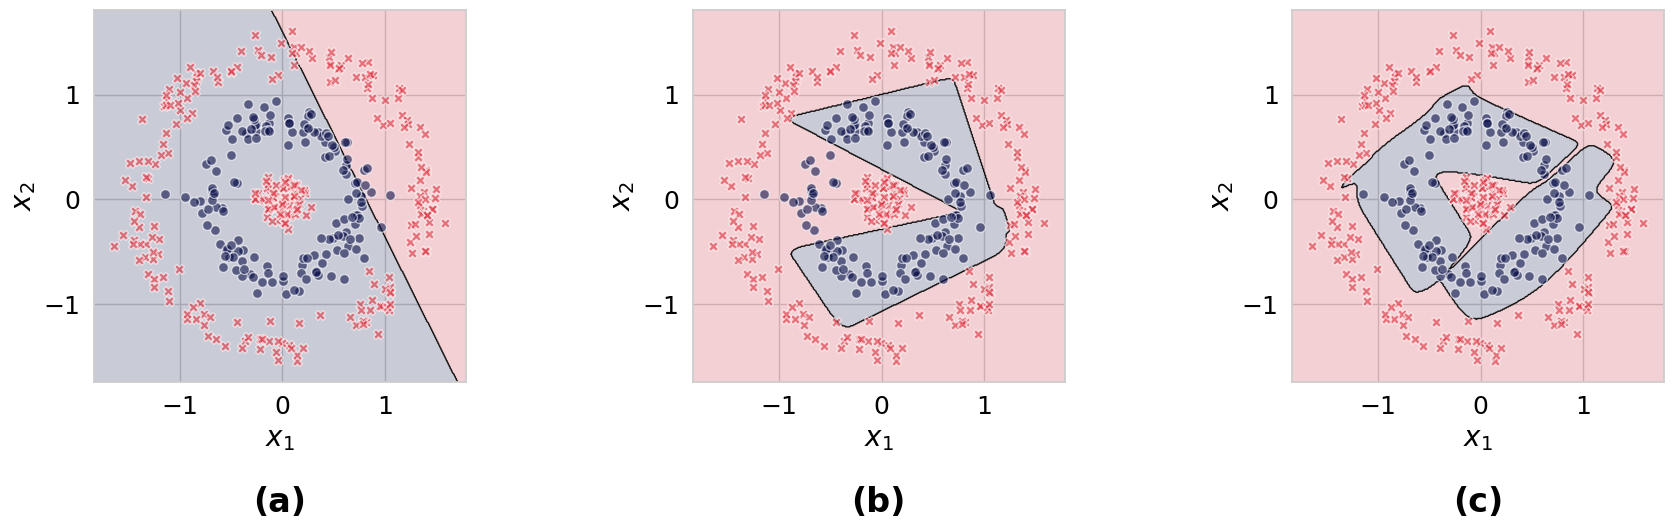

In [4]:
# --- CONFIGURAÇÃO E TREINAMENTO DOS MODELOS ---

# Modelo 1: Perceptron Simples (Apenas uma reta, o caso base linear)
modelo_1 = Perceptron(random_state=28, max_iter=1000)
modelo_1.fit(X, y)

# Modelo 2: MLP com 1 Camada Oculta (8 Neurônios, Ativação Sigmóide)
# Usamos a semente 2802 para garantir que a inicialização dos pesos resulte na 
# exata forma visual que queremos demonstrar aos alunos na apostila.
modelo_2 = MLPClassifier(hidden_layer_sizes=(8,), activation='logistic', 
                         solver='lbfgs', max_iter=2000, random_state=2802)
modelo_2.fit(X, y)

# Modelo 3: MLP com 2 Camadas Ocultas (8 Neurônios em cada, Ativação Sigmóide)
# A segunda camada atuará como um "compositor" das formas criadas pela primeira.
modelo_3 = MLPClassifier(hidden_layer_sizes=(8, 8), activation='logistic', 
                         solver='lbfgs', max_iter=2000, random_state=2802)
modelo_3.fit(X, y)

modelos = [modelo_1, modelo_2, modelo_3]
subtitulos = ['(a)', '(b)', '(c)']

# --- PREPARAÇÃO DO GRID PARA PLOTAGEM DO FUNDO ---
h = 0.01  # Alta resolução para garantir que a fronteira gerada pelo pcolormesh fique limpa
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Colormap para a pintura das regiões de decisão (Cores institucionais)
cmap_fundo = ListedColormap([COR_VERMELHO, COR_AZUL_PRINCIPAL])

# --- GERAÇÃO DOS PLOTS ---
fig, eixos = plt.subplots(1, 3, figsize=(18, 6))

for ax, modelo, subtitulo in zip(eixos, modelos, subtitulos):
    
    # 1. Previsão da classe para cada ponto da malha (Plano Cartesiano Inteiro)
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 2. Pintura do Fundo da Região de Decisão
    # Usamos alpha=0.2 para deixar o fundo translúcido e não ofuscar os dados
    ax.pcolormesh(xx, yy, Z, cmap=cmap_fundo, alpha=0.2, shading='auto', zorder=1)
    
    # 3. Desenho da Linha de Contorno (Fronteira de Decisão Matemática)
    try:
        ax.contour(xx, yy, Z, levels=[0.5], colors=[COR_PRETO], linewidths=1.0, alpha=0.9, zorder=2)
    except UserWarning:
        pass # Se o modelo linear errar tudo e pintar apenas uma cor, não haverá linha para traçar
    
    # 4. Plotagem dos dados reais com ajustes visuais
    for classe in np.unique(y):
        idx = np.where(y == classe)
        cor = COR_VERMELHO if classe == 0 else COR_AZUL_PRINCIPAL
        marcador = 'X' if classe == 0 else 'o'
        
        # Dados com opacidade 0.6 para dar contraste com as linhas sólidas pretas
        ax.scatter(X[idx, 0], X[idx, 1], c=cor, marker=marcador, 
                   edgecolor=COR_BRANCO, s=50, linewidth=1.0, alpha=0.6, zorder=3)

    # --- REGRAS DE DIAGRAMAÇÃO E TIPOGRAFIA (Padrão PDF) ---
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_box_aspect(1) # Força proporção simétrica geométrica
    
    # Labels em Raw Strings para evitar alertas do Matplotlib
    ax.set_xlabel(r'$x_1$', fontsize=FONT_LABEL, color=COR_PRETO)
    ax.set_ylabel(r'$x_2$', fontsize=FONT_LABEL, color=COR_PRETO)
    ax.tick_params(axis='both', labelsize=FONT_TICK, colors=COR_PRETO)
    
    # Ancoragem padronizada das letras de subfigura
    ax.text(0.5, -0.35, subtitulo, transform=ax.transAxes, ha='center', 
            fontweight='bold', fontsize=FONT_SUBFIGURE, color=COR_PRETO)

# Ajustes de Espaçamento com respiro adequado para evitar cortes em documentos
plt.tight_layout(w_pad=2.0)
fig.subplots_adjust(bottom=0.35)

# --- SALVAMENTO ---
caminho_save = os.path.join('..', 'outputs', 'figures', 'aula_06')
os.makedirs(caminho_save, exist_ok=True)
plt.savefig(os.path.join(caminho_save, '03_mlp_fronteiras_evolucao_complexo.png'), 
            dpi=300, bbox_inches='tight', pad_inches=0.4)

plt.show()

### Análise Matemática e Estrutural
O distanciamento dos grupos aliados aos limites intencionais na capacidade das redes ilustram brilhantemente a topologia do aprendizado:
* **Subfigura (a) - Perceptron**: Permanece traçando uma única reta. O modelo não tem parâmetros suficientes para curvar o espaço, sendo incapaz de resolver o problema concêntrico.
* **Subfigura (b) - MLP com 1 Camada Oculta (8 Neurônios)**: O modelo utiliza seus 8 neurônios na tentativa de criar "barreiras matemáticas". Embora o contorno comece a ganhar uma forma arredondada graças à função de ativação Sigmóide, a rede isolada sofre para "fechar" o anel azul perfeitamente sem gerar extensões ou deformidades na região vermelha, revelando as limitações de redes rasas frente a inseparabilidades duplas.
* **Subfigura (c) - MLP com 2 Camadas Ocultas (8x8 Neurônios)**: Aqui o verdadeiro poder arquitetural se revela. A segunda camada age combinando e suavizando as representações geradas pela primeira. O resultado é um contorno liso, contínuo e orgânico que abraça a "rosquinha" azul com extrema elegância, provando visualmente como o simples acréscimo de uma nova camada oculta refina exponencialmente a capacidade de mapeamento da Inteligência Artificial.